# Data Amount Experiment：

Setup:
- Keep validation and test splits fixed
- Keep model fixed (`tds_conv_ctc`)
- Vary only the number of training sessions
- Compare `val_CER` and `test_CER` against training data amount

In [2]:
from pathlib import Path
import os

CANDIDATES = [
    Path('/content/drive/MyDrive/emg2qwerty'),
    Path('/content/emg2qwerty'),
    Path('/Users/byte/Library/CloudStorage/GoogleDrive-zijiezh@g.ucla.edu/My Drive/emg2qwerty'),
]
REPO = next((p for p in CANDIDATES if p.exists()), None)
if REPO is None:
    raise FileNotFoundError('Could not find repo in known locations.')

os.chdir(REPO)
print('Working directory:', Path.cwd())

Working directory: /content/drive/MyDrive/emg2qwerty


In [3]:
import importlib
import sys

required = ['hydra', 'pytorch_lightning', 'torch', 'tensorboard', 'yaml']
missing = [pkg for pkg in required if importlib.util.find_spec(pkg) is None]
print('Python:', sys.executable)
if missing:
    print('Missing packages:', missing)
    print('Install with: pip install -r requirements.txt && pip install -e .')
else:
    print('All required packages found.')

Python: /usr/bin/python3
All required packages found.


In [ ]:
import random
from pathlib import Path
import yaml

SEED = 1501
BASE_USER_CONFIG = REPO / 'config' / 'user' / 'single_user.yaml'
GENERATED_USER_DIR = REPO / 'config' / 'user' / 'data_amount_generated'
GENERATED_USER_DIR.mkdir(parents=True, exist_ok=True)

cfg = yaml.safe_load(BASE_USER_CONFIG.read_text())
full_train = cfg['dataset']['train']
val_split = cfg['dataset']['val']
test_split = cfg['dataset']['test']

rng = random.Random(SEED)
shuffled_train = full_train.copy()
rng.shuffle(shuffled_train)

TRAIN_SESSION_COUNTS = [1, 2, 4, 8, 12]
TRAIN_SESSION_COUNTS = sorted(set(TRAIN_SESSION_COUNTS))

subset_specs = []
for n in TRAIN_SESSION_COUNTS:
    subset_name = f'data_amount_{n:02d}_sessions'
    subset_cfg = {
        'user': subset_name,
        'dataset': {
            'train': shuffled_train[:n],
            'val': val_split,
            'test': test_split,
        },
    }
    subset_path = GENERATED_USER_DIR / f'{subset_name}.yaml'
    subset_path.write_text('# @package _global_\n' + yaml.safe_dump(subset_cfg, sort_keys=False))
    subset_specs.append(
        {
            'name': subset_name,
            'num_train_sessions': n,
            'train_fraction': n / len(shuffled_train),
            'config_path': subset_path,
        }
    )

print('Generated subset configs:')
for spec in subset_specs:
    print(spec['name'], '| sessions =', spec['num_train_sessions'], '| fraction =', f"{spec['train_fraction']:.2f}")

Generated subset configs:
data_amount_01_sessions | sessions = 1 | fraction = 0.06
data_amount_02_sessions | sessions = 2 | fraction = 0.12
data_amount_04_sessions | sessions = 4 | fraction = 0.25
data_amount_08_sessions | sessions = 8 | fraction = 0.50
data_amount_12_sessions | sessions = 12 | fraction = 0.75


In [ ]:
import os
import subprocess
import sys
import time
from collections import deque


def has_gpu() -> bool:
    try:
        import torch
        return bool(torch.cuda.is_available())
    except Exception:
        return False


def preflight_data_check() -> None:
    data_root = REPO / 'data'
    if not data_root.exists():
        raise FileNotFoundError(f'Missing data directory: {data_root}')

    missing = []
    for item in full_train + val_split + test_split:
        hdf5_path = data_root / f"{item['session']}.hdf5"
        if not hdf5_path.exists():
            missing.append(hdf5_path)

    if missing:
        preview = '\n'.join(str(p) for p in missing[:10])
        raise FileNotFoundError(
            f'Missing {len(missing)} data files under {data_root}. First 10:\n{preview}'
        )

    print('Preflight data check passed.')


ACCELERATOR = 'gpu' if has_gpu() else 'cpu'
MAX_EPOCHS = 40
AUTO_FALLBACK_TO_CPU = True
BASE_MODEL = 'tds_conv_ctc'

print('Accelerator:', ACCELERATOR)
print('Max epochs:', MAX_EPOCHS)
preflight_data_check()


def run_dir_for(spec_name: str, accel: str) -> Path:
    return REPO / 'logs' / 'data_amount_experiment' / 'runs' / f'{spec_name}_{accel}'


def build_args(spec: dict, accel: str):
    run_dir = run_dir_for(spec['name'], accel)
    user_override = f"user=data_amount_generated/{spec['name']}"
    return [
        f'model={BASE_MODEL}',
        user_override,
        f'trainer.accelerator={accel}',
        'trainer.devices=1',
        f'trainer.max_epochs={MAX_EPOCHS}',
        '+trainer.enable_progress_bar=true',
        f'hydra.run.dir={run_dir}',
        'num_workers=0',
    ]


def run_with_live_output(cmd, log_file: Path):
    tail = deque(maxlen=120)
    env = os.environ.copy()
    env['HYDRA_FULL_ERROR'] = '1'

    log_file.parent.mkdir(parents=True, exist_ok=True)
    with log_file.open('w', encoding='utf-8') as lf:
        proc = subprocess.Popen(
            cmd,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
            env=env,
        )
        assert proc.stdout is not None
        for line in proc.stdout:
            print(line, end='')
            lf.write(line)
            tail.append(line.rstrip('\n'))

        ret = proc.wait()

    if ret != 0:
        print(f'\nFull log saved to: {log_file}')
        print('\n----- Last 120 log lines -----')
        print('\n'.join(tail))
        raise RuntimeError(f'Command failed with exit code {ret}')


def run_experiment(spec: dict, accel: str):
    run_dir = run_dir_for(spec['name'], accel)
    last_ckpt = run_dir / 'checkpoints' / 'last.ckpt'
    if last_ckpt.exists():
        print(f'Resuming from existing checkpoint: {last_ckpt}')

    cmd = [sys.executable, '-m', 'emg2qwerty.train', *build_args(spec, accel)]
    print('\nRunning:', ' '.join(cmd), flush=True)

    start = time.time()
    log_file = REPO / 'logs' / 'data_amount_experiment' / f"{spec['name']}_{accel}.log"
    run_with_live_output(cmd, log_file)
    elapsed_min = (time.time() - start) / 60.0
    print(f"{spec['name']} completed successfully on {accel} in {elapsed_min:.1f} min.")


for i, spec in enumerate(subset_specs, start=1):
    print(
        f"\n===== Experiment {i}/{len(subset_specs)}: {spec['name']} "
        f"({spec['num_train_sessions']} sessions, {spec['train_fraction']:.0%}) ====="
    )
    try:
        run_experiment(spec, ACCELERATOR)
    except Exception as e:
        if ACCELERATOR == 'gpu' and AUTO_FALLBACK_TO_CPU:
            print(f"\nGPU run failed for {spec['name']}: {e}")
            print('Retrying once on CPU...')
            run_experiment(spec, 'cpu')
        else:
            raise

print('\nAll data-amount experiments completed.')

Accelerator: gpu
Max epochs: 40
Preflight data check passed.

===== Experiment 1/6: data_amount_01_sessions (1 sessions, 6%) =====

Running: /usr/bin/python3 -m emg2qwerty.train model=tds_conv_ctc user=data_amount_generated/data_amount_01_sessions trainer.accelerator=gpu trainer.devices=1 trainer.max_epochs=40 +trainer.enable_progress_bar=true hydra.run.dir=/content/drive/MyDrive/emg2qwerty/logs/data_amount_experiment/runs/data_amount_01_sessions_gpu num_workers=0
[2026-03-07 00:17:24,799][__main__][INFO] - 
Config:
user: data_amount_01_sessions
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622764398-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  val:
  - user: 89335547
    session: 2021-06-04-1622862148-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  test:
  - user: 89335547
    session: 2021-06-02-1622682789-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  root: ${hydra:runtime.cwd}/data
to_tensor:
  _target_: emg2qwerty.trans

In [ ]:
from pathlib import Path
import csv
import math
import pandas as pd
from tensorboard.backend.event_processing import event_accumulator


def latest_scalar_across_files(event_files: list[Path], tag: str):
    latest = None
    for event_file in event_files:
        ea = event_accumulator.EventAccumulator(str(event_file))
        ea.Reload()
        scalar_tags = ea.Tags().get("scalars", [])

        if tag in scalar_tags:
            candidates = [tag]
        else:
            candidates = [t for t in scalar_tags if t.endswith(tag)]

        for t in candidates:
            events = ea.Scalars(t)
            if not events:
                continue
            e = events[-1]
            if latest is None or e.wall_time > latest[0]:
                latest = (e.wall_time, e.value)

    return None if latest is None else latest[1]


def parse_run_name(run_dir: Path) -> tuple[str, str]:
    name = run_dir.name
    if name.endswith("_gpu"):
        return name[:-4], "gpu"
    if name.endswith("_cpu"):
        return name[:-4], "cpu"
    return name, "unknown"


def to_float_or_none(value):
    if value is None or value == "":
        return None
    try:
        return float(value)
    except (TypeError, ValueError):
        return None


def is_present(value) -> bool:
    if value is None:
        return False
    if isinstance(value, float) and math.isnan(value):
        return False
    return True


spec_lookup = {spec["name"]: spec for spec in subset_specs}
runs_root = REPO / "logs" / "data_amount_experiment" / "runs"
run_dirs = sorted([p for p in runs_root.glob("*") if p.is_dir()])
print(f"Found {len(run_dirs)} run dirs under {runs_root}")

rows = []
for run_dir in run_dirs:
    event_files = sorted(
        run_dir.glob("lightning_logs/**/events.out.tfevents.*"),
        key=lambda p: p.stat().st_mtime,
    )
    if not event_files:
        continue

    spec_name, accel = parse_run_name(run_dir)
    spec = spec_lookup.get(spec_name)
    if spec is None:
        continue

    latest_event = event_files[-1]
    rows.append(
        {
            "experiment": spec_name,
            "accelerator": accel,
            "num_train_sessions": int(spec["num_train_sessions"]),
            "train_fraction": float(spec["train_fraction"]),
            "run_dir": str(run_dir),
            "event_file": str(latest_event),
            "val_CER": latest_scalar_across_files(event_files, "val/CER"),
            "test_CER": latest_scalar_across_files(event_files, "test/CER"),
            "val_loss": latest_scalar_across_files(event_files, "val/loss"),
            "test_loss": latest_scalar_across_files(event_files, "test/loss"),
        }
    )

# Add old 100% data result from the previous full-data architecture run.
full_csv = REPO / "architecture_metrics_summary.csv"
if full_csv.exists():
    with open(full_csv, "r", newline="") as f:
        reader = csv.DictReader(f)
        old_rows = [row for row in reader if row.get("model") == "tds_conv_ctc"]

    if old_rows:
        old_full = old_rows[0]
        old_run_dir = old_full.get("run_dir")
        old_event_file = old_full.get("event_file")

        old_event_files = []
        if old_run_dir:
            old_event_files = sorted(
                Path(old_run_dir).glob("lightning_logs/**/events.out.tfevents.*"),
                key=lambda p: p.stat().st_mtime,
            )

        old_val_cer = latest_scalar_across_files(old_event_files, "val/CER") if old_event_files else None
        old_test_cer = latest_scalar_across_files(old_event_files, "test/CER") if old_event_files else None
        old_val_loss = latest_scalar_across_files(old_event_files, "val/loss") if old_event_files else None
        old_test_loss = latest_scalar_across_files(old_event_files, "test/loss") if old_event_files else None

        if old_val_cer is None:
            old_val_cer = to_float_or_none(old_full.get("val_CER"))
        if old_test_cer is None:
            old_test_cer = to_float_or_none(old_full.get("test_CER"))
        if old_val_loss is None:
            old_val_loss = to_float_or_none(old_full.get("val_loss"))
        if old_test_loss is None:
            old_test_loss = to_float_or_none(old_full.get("test_loss"))

        rows.append(
            {
                "experiment": "data_amount_16_sessions_old",
                "accelerator": "gpu",
                "num_train_sessions": 16,
                "train_fraction": 1.0,
                "run_dir": old_run_dir,
                "event_file": old_event_file,
                "val_CER": old_val_cer,
                "test_CER": old_test_cer,
                "val_loss": old_val_loss,
                "test_loss": old_test_loss,
            }
        )

rows_by_session = {}
for row in rows:
    rows_by_session[row["num_train_sessions"]] = row

ordered_rows = [rows_by_session[k] for k in sorted(rows_by_session)]
for row in ordered_rows:
    row["status"] = "complete" if is_present(row.get("test_CER")) else "in_progress"

results_df = pd.DataFrame(ordered_rows)

print('Loaded results into `results_df`:')
for row in ordered_rows:
    print(
        row['experiment'],
        '| sessions =', row['num_train_sessions'],
        '| fraction =', f"{row['train_fraction']:.2f}",
        '| val_CER =', row['val_CER'],
        '| test_CER =', row['test_CER'],
        '| status =', row['status'],
    )

Found 6 run dirs under /content/drive/MyDrive/emg2qwerty/logs/data_amount_experiment/runs
Loaded results into `results_df`:
data_amount_01_sessions | sessions = 1 | fraction = 0.06 | val_CER = 95.54718780517578 | test_CER = 99.97838592529297 | status = complete
data_amount_02_sessions | sessions = 2 | fraction = 0.12 | val_CER = 99.86708068847656 | test_CER = 100.0 | status = complete
data_amount_04_sessions | sessions = 4 | fraction = 0.25 | val_CER = 88.52458953857422 | test_CER = 89.5828857421875 | status = complete
data_amount_08_sessions | sessions = 8 | fraction = 0.50 | val_CER = 57.50996780395508 | test_CER = 58.3315315246582 | status = complete
data_amount_12_sessions | sessions = 12 | fraction = 0.75 | val_CER = 29.90695571899414 | test_CER = 30.51653289794922 | status = complete
data_amount_16_sessions_old | sessions = 16 | fraction = 1.00 | val_CER = 23.548959732055664 | test_CER = 25.480873107910156 | status = complete


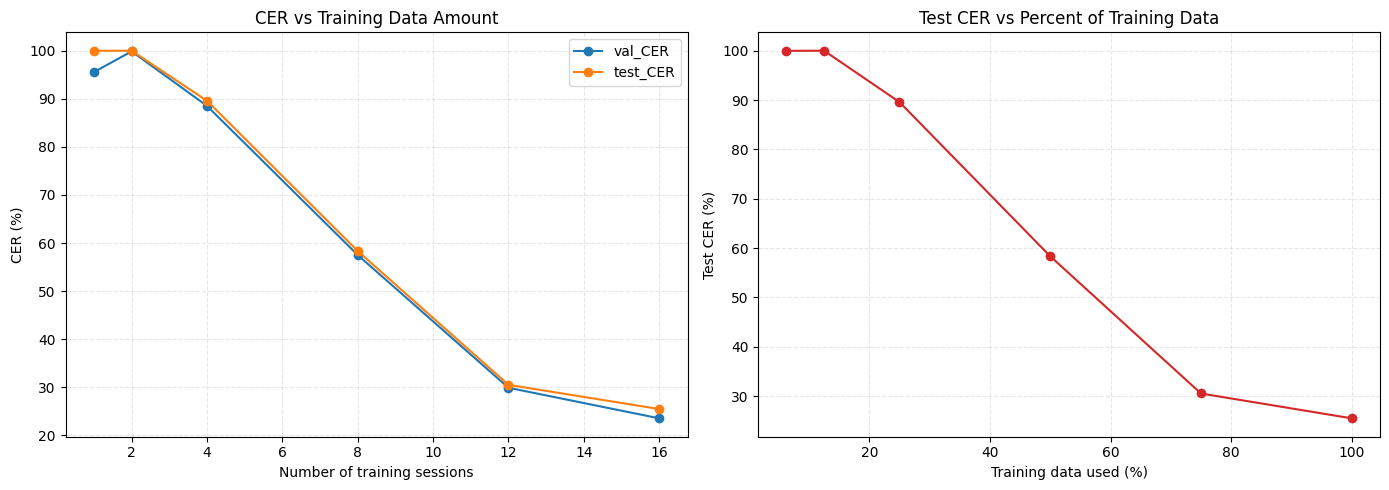

Plot summary:
data_amount_01_sessions | sessions = 1 | fraction = 0.06 | val_CER = 95.54718780517578 | test_CER = 99.97838592529297 | status = complete
data_amount_02_sessions | sessions = 2 | fraction = 0.12 | val_CER = 99.86708068847656 | test_CER = 100.0 | status = complete
data_amount_04_sessions | sessions = 4 | fraction = 0.25 | val_CER = 88.52458953857422 | test_CER = 89.5828857421875 | status = complete
data_amount_08_sessions | sessions = 8 | fraction = 0.50 | val_CER = 57.50996780395508 | test_CER = 58.3315315246582 | status = complete
data_amount_12_sessions | sessions = 12 | fraction = 0.75 | val_CER = 29.90695571899414 | test_CER = 30.51653289794922 | status = complete
data_amount_16_sessions_old | sessions = 16 | fraction = 1.00 | val_CER = 23.548959732055664 | test_CER = 25.480873107910156 | status = complete


In [17]:
import matplotlib.pyplot as plt

if results_df.empty:
    print('No results to plot yet. Run training and metrics extraction first.')
else:
    records = results_df.to_dict('records')
    records = sorted(records, key=lambda r: r['num_train_sessions'])
    plot_df = pd.DataFrame(records)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(plot_df['num_train_sessions'], plot_df['val_CER'], marker='o', label='val_CER')
    axes[0].plot(plot_df['num_train_sessions'], plot_df['test_CER'], marker='o', label='test_CER')
    axes[0].set_title('CER vs Training Data Amount')
    axes[0].set_xlabel('Number of training sessions')
    axes[0].set_ylabel('CER (%)')
    axes[0].grid(True, linestyle='--', alpha=0.3)
    axes[0].legend()

    axes[1].plot(plot_df['train_fraction'] * 100, plot_df['test_CER'], marker='o', color='tab:red')
    axes[1].set_title('Test CER vs Percent of Training Data')
    axes[1].set_xlabel('Training data used (%)')
    axes[1].set_ylabel('Test CER (%)')
    axes[1].grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print('Plot summary:')
    for row in records:
        print(
            row['experiment'],
            '| sessions =', row['num_train_sessions'],
            '| fraction =', f"{row['train_fraction']:.2f}",
            '| val_CER =', row['val_CER'],
            '| test_CER =', row['test_CER'],
            '| status =', row['status'],
        )

In [ ]:
import csv

out_csv = REPO / 'data_amount_metrics_summary.csv'

rows_to_save = ordered_rows if 'ordered_rows' in globals() else []
if not rows_to_save and 'results_df' in globals():
    try:
        rows_to_save = results_df.to_dict('records')
    except Exception:
        rows_to_save = []

if not rows_to_save:
    raise RuntimeError('No rows available to save. Run the metrics extraction cell first.')

fieldnames = [
    'experiment', 'accelerator', 'num_train_sessions', 'train_fraction',
    'run_dir', 'event_file', 'val_CER', 'test_CER', 'val_loss', 'test_loss', 'status'
]

with open(out_csv, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for row in rows_to_save:
        writer.writerow({k: row.get(k) for k in fieldnames})

print('Saved:', out_csv)
print('Rows saved:', len(rows_to_save))

Saved: /content/drive/MyDrive/emg2qwerty/data_amount_metrics_summary.csv
Rows saved: 6
